In [2]:
#Importing packages for EDA

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [5]:
#Importing the CSV File
df=pd.read_csv("C:/Users/Shravani Angalagunta/Downloads/Heart_disease_cleveland_new.csv") 

In [6]:
#Display 5 rows of the dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
#Descriptive Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,2.158416,0.960126,0.0,2.0,2.0,3.0,3.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [11]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

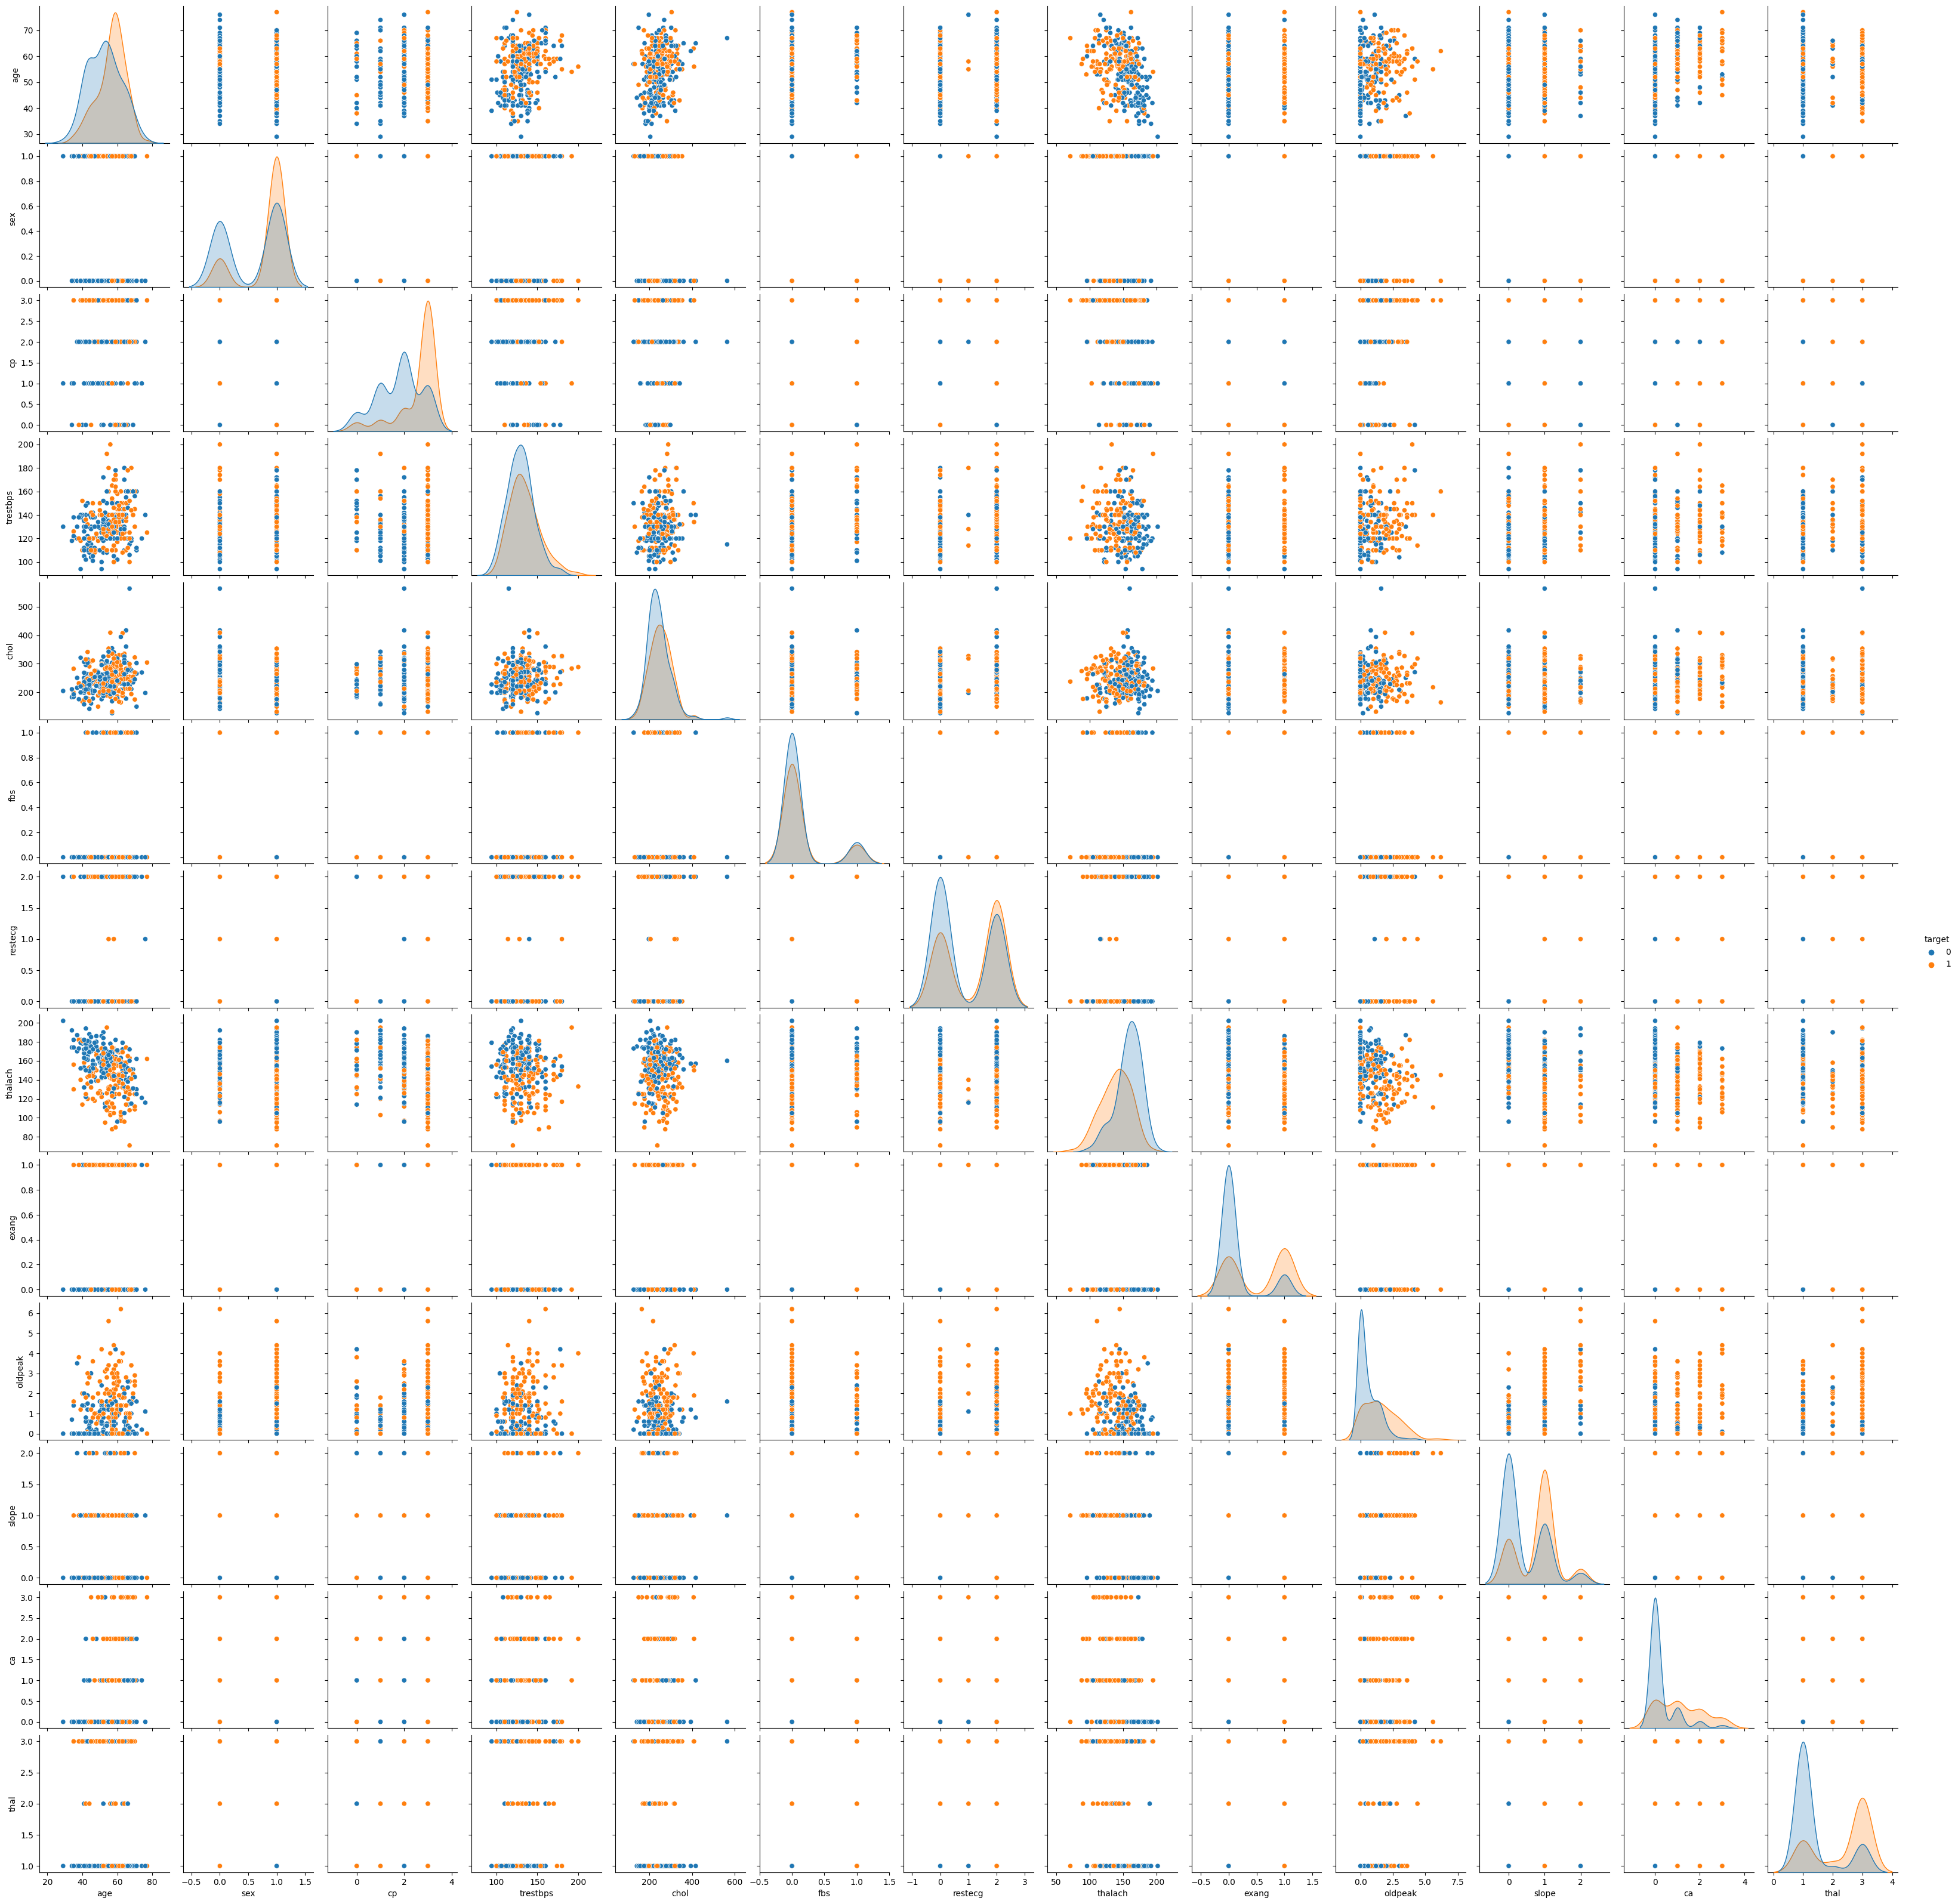

In [12]:
#Pair plot of Variables based on target
sns.pairplot(df,hue='target')

<Axes: xlabel='target', ylabel='count'>

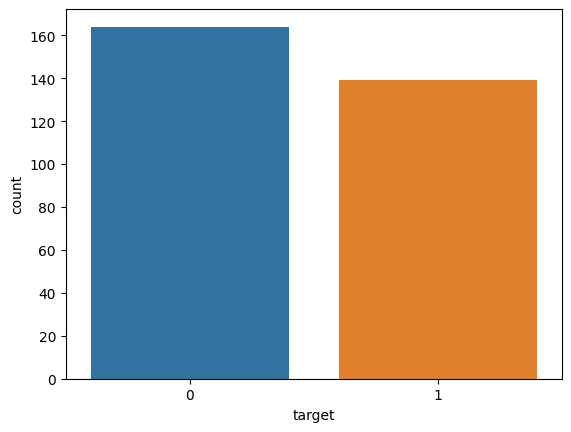

In [14]:
#Count of the number of patients with diseases vs with no diseases
sns.countplot(x='target', data = df)

<Axes: ylabel='count'>

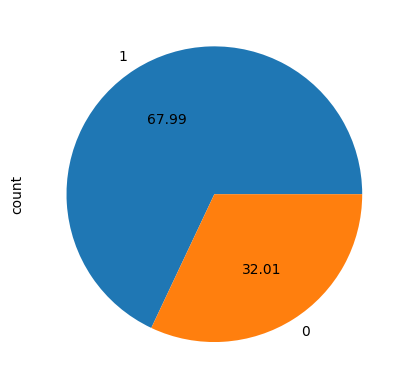

In [15]:
#Pie chart showing the percentage of male patients vs female
df['sex'].value_counts().plot.pie(autopct='%.2f')

<Axes: xlabel='cp', ylabel='age'>

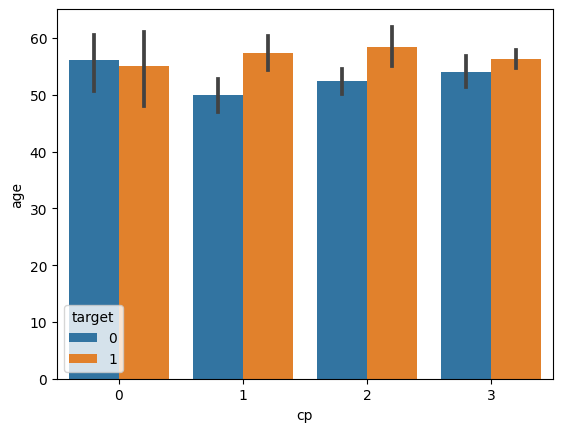

In [17]:
#Chest pain type based on Target variable
sns.barplot(y='age',x='cp',data=df,hue='target')


<Axes: xlabel='age', ylabel='Density'>

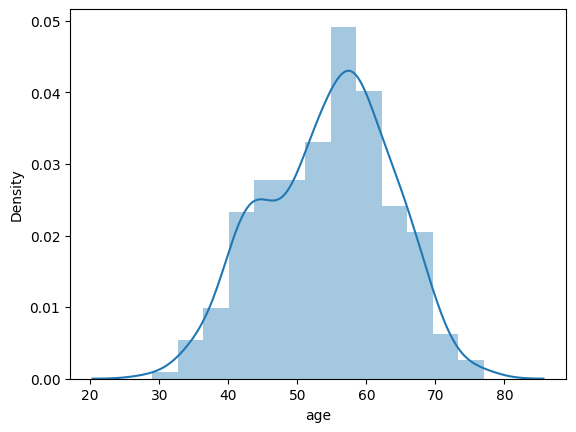

In [19]:
#Distribution of the age of the patients
sns.distplot(df['age'], kde=True)

<Axes: >

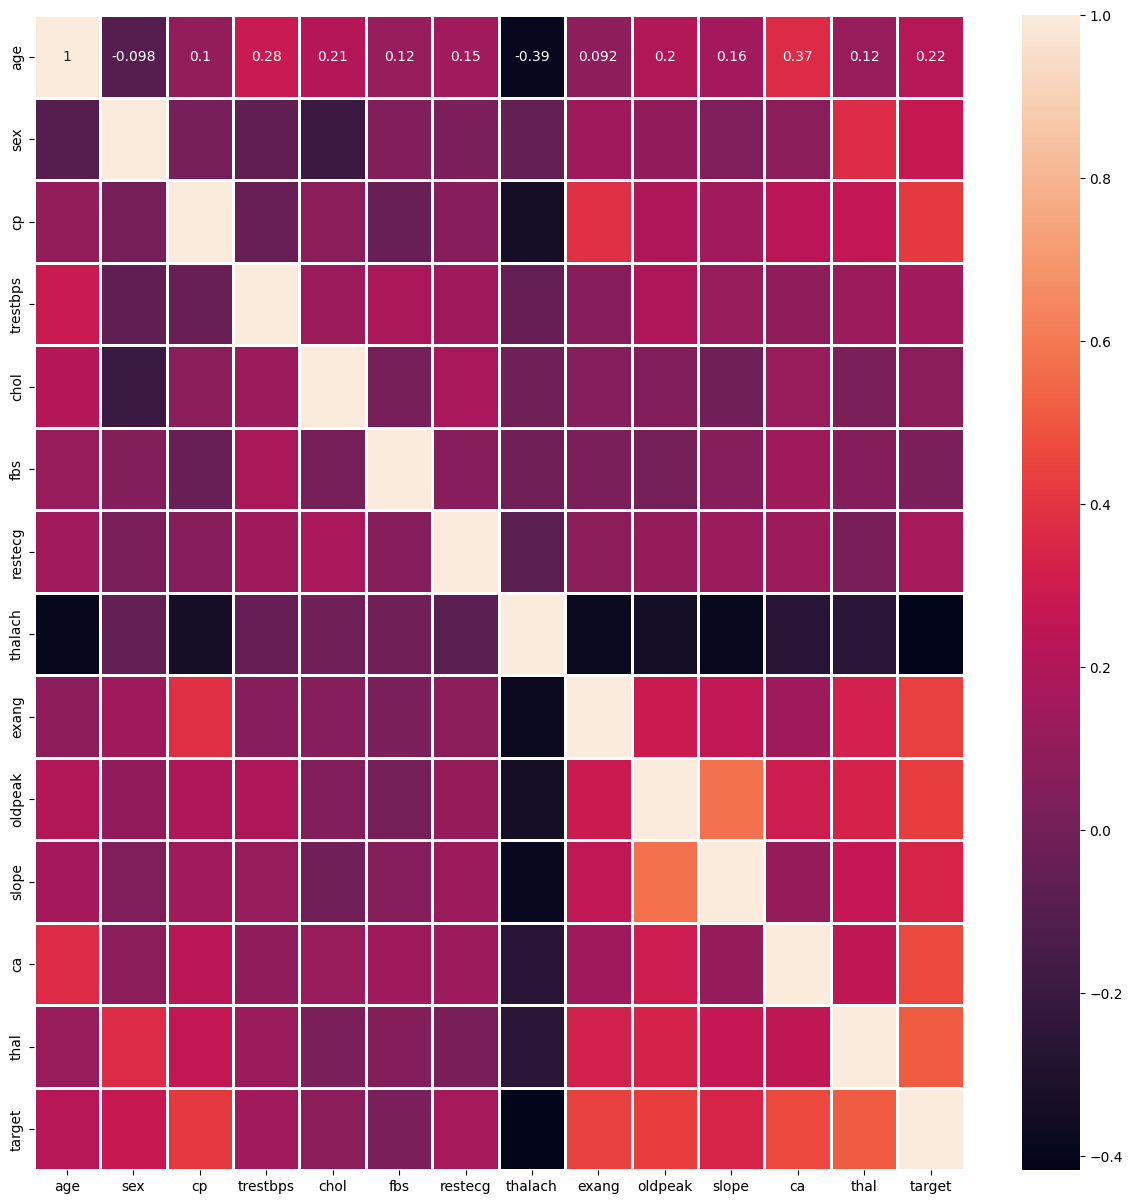

In [20]:
#Correlation graph of all variables
corr=df.corr()
plt.figure(figsize= (15,15))
sns.heatmap(corr, linewidth=1,annot=True,linecolor='white')

In [21]:
#Defining the independent X variables and dependent y variables
X = df.drop('target', axis=1)
y = df['target']

In [22]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [24]:
#Logistic Regression
from sklearn.linear_model import  LogisticRegression
lr=LogisticRegression()
model_lr=lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [26]:
cm_lr=confusion_matrix(y_test,pred_lr)
print("Confusion Matrix   :", cm_lr)
accuracy_lr = accuracy_score(y_test, pred_lr)
print("Accuracy   :", accuracy_lr)
precision_lr = precision_score(y_test, pred_lr)
print("Precision :", precision_lr)
recall_lr = recall_score(y_test, pred_lr)
print("Recall    :", recall_lr)
F1_score_lr = f1_score(y_test, pred_lr)
print("F1-score  :", F1_score_lr)

Confusion Matrix   : [[43  5]
 [ 6 37]]
Accuracy   : 0.8791208791208791
Precision : 0.8809523809523809
Recall    : 0.8604651162790697
F1-score  : 0.8705882352941177


In [28]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=5)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [29]:
cm_rf=confusion_matrix(y_test,pred_rf)
print("Confusion Matrix   :", cm_rf)
accuracy_rf = accuracy_score(y_test, pred_rf)
print("Accuracy   :", accuracy_rf)
precision_rf = precision_score(y_test, pred_rf)
print("Precision :", precision_rf)
recall_rf = recall_score(y_test, pred_rf)
print("Recall    :", recall_rf)
F1_score_rf = f1_score(y_test, pred_rf)
print("F1-score  :", F1_score_rf)

Confusion Matrix   : [[41  7]
 [ 6 37]]
Accuracy   : 0.8571428571428571
Precision : 0.8409090909090909
Recall    : 0.8604651162790697
F1-score  : 0.8505747126436781


In [30]:
#Support Vector Machine(SVM)
from sklearn.svm import SVC
svc =  SVC(C=2)
svc.fit(X_train, y_train)
pred_svm = svc.predict(X_test)

In [31]:
cm_svm=confusion_matrix(y_test,pred_svm)
print("Confusion Matrix   :", cm_svm)
accuracy_svm = accuracy_score(y_test, pred_svm)
print("Accuracy   :", accuracy_svm)
precision_svm = precision_score(y_test, pred_svm)
print("Precision :", precision_svm)
recall_svm = recall_score(y_test, pred_svm)
print("Recall    :", recall_svm)
F1_score_svm = f1_score(y_test, pred_svm)
print("F1-score  :", F1_score_svm)

Confusion Matrix   : [[40  8]
 [ 8 35]]
Accuracy   : 0.8241758241758241
Precision : 0.813953488372093
Recall    : 0.813953488372093
F1-score  : 0.813953488372093


In [32]:
#KNN Method
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

In [33]:
cm_knn=confusion_matrix(y_test,pred_knn)
print("Confusion Matrix   :", cm_knn)
accuracy_knn = accuracy_score(y_test, pred_knn)
print("Accuracy   :", accuracy_knn)
precision_knn = precision_score(y_test, pred_knn)
print("Precision :", precision_knn)
recall_knn = recall_score(y_test, pred_knn)
print("Recall    :", recall_knn)
F1_score_knn= f1_score(y_test, pred_knn)
print("F1-score  :", F1_score_knn)

Confusion Matrix   : [[40  8]
 [ 8 35]]
Accuracy   : 0.8241758241758241
Precision : 0.813953488372093
Recall    : 0.813953488372093
F1-score  : 0.813953488372093


In [36]:
#Extreme Gradient Boosting (XG Boost)
from xgboost import XGBClassifier
xg = XGBClassifier(learning_rate=0.05, n_estimators=100, max_depth=15)
xg.fit(X_train, y_train)
pred_xg = xg.predict(X_test)

In [37]:
cm_xg=confusion_matrix(y_test,pred_xg)
print("Confusion Matrix   :", cm_xg)
accuracy_xg = accuracy_score(y_test, pred_xg)
print("Accuracy   :", accuracy_xg)
precision_xg = precision_score(y_test, pred_xg)
print("Precision :", precision_xg)
recall_xg = recall_score(y_test, pred_xg)
print("Recall    :", recall_xg)
F1_score_xg = f1_score(y_test, pred_xg)
print("F1-score  :", F1_score_xg)

Confusion Matrix   : [[47  1]
 [36  7]]
Accuracy   : 0.5934065934065934
Precision : 0.875
Recall    : 0.16279069767441862
F1-score  : 0.27450980392156865


In [38]:
#XG Boost(Alternate method)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

xg = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10, 15],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_lambda': [0.1, 1, 5],
    'reg_alpha': [0, 0.1, 0.5]
}

random_search = RandomizedSearchCV(
    estimator=xg,
    param_distributions=param_grid,
    scoring='accuracy',
    n_iter=50,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 1.0}
Best Accuracy: 0.8490586932447398


In [39]:
best_xg = random_search.best_estimator_
y_pred = best_xg.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test Accuracy: 0.5604395604395604
              precision    recall  f1-score   support

           0       0.55      0.98      0.70        48
           1       0.80      0.09      0.17        43

    accuracy                           0.56        91
   macro avg       0.67      0.54      0.43        91
weighted avg       0.67      0.56      0.45        91



In [47]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Optional: scale data for stability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optimized XGBoost model
xg = XGBClassifier(
    learning_rate=0.03,       # smaller step size → better generalization
    n_estimators=600,         # more trees since learning rate is smaller
    max_depth=5,              # avoids overfitting (15 was too large)
    min_child_weight=3,       # controls overfitting by minimum leaf weight
    gamma=0.2,                # regularization term for split decisions
    subsample=0.8,            # prevents overfitting by random row sampling
    colsample_bytree=0.8,     # random feature sampling per tree
    reg_lambda=1,             # L2 regularization
    reg_alpha=0.1,            # L1 regularization
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train the model
xg.fit(X_train_scaled, y_train)

# Predict and evaluate
pred_xg = xg.predict(X_test_scaled)
acc = accuracy_score(y_test, pred_xg)

print("Optimized XGBoost Accuracy:", acc)
print(classification_report(y_test, pred_xg))


Optimized XGBoost Accuracy: 0.8852459016393442
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



 Random Forest Accuracy: 90.16%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



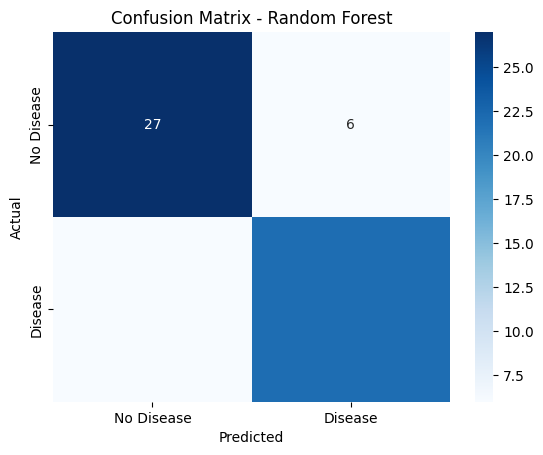

In [58]:
#Random Forest Model
import seaborn as sns
import matplotlib.pyplot as plt
# Initialize Random Forest with tuned hyperparameters
rf = RandomForestClassifier(
    n_estimators=300,       # number of trees
    max_depth=8,            # prevent overfitting
    min_samples_split=5,    # min samples to split node
    min_samples_leaf=2,     # min samples per leaf
    max_features='sqrt',    # number of features per split
    bootstrap=True,         # bootstrap sampling
    random_state=42,
    n_jobs=-1               # parallel processing
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf.predict(X_test_scaled)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f" Random Forest Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrixrf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [64]:
cm_xg_alternate = confusion_matrix(y_test, y_pred)
print("Confusion Matrix   :", cm_xg_alternate)
accuracy_xg_alternate = accuracy_score(y_test, y_pred)
print("Accuracy   :", accuracy_xg_alternate)
precision_xg_alternate = precision_score(y_test, y_pred)
print("Precision :", precision_xg_alternate)
recall_xg_alternate = recall_score(y_test, y_pred)
print("Recall    :", recall_xg_alternate)
F1_score_xg_alternate = f1_score(y_test, y_pred)
print("F1-score  :", F1_score_xg_alternate)

Confusion Matrix   : [[29  4]
 [ 2 26]]
Accuracy   : 0.9016393442622951
Precision : 0.8666666666666667
Recall    : 0.9285714285714286
F1-score  : 0.896551724137931


 Decision Tree Accuracy: 80.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        33
           1       0.79      0.79      0.79        28

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



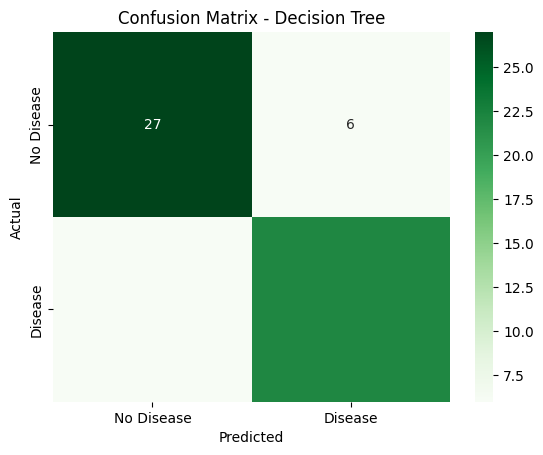

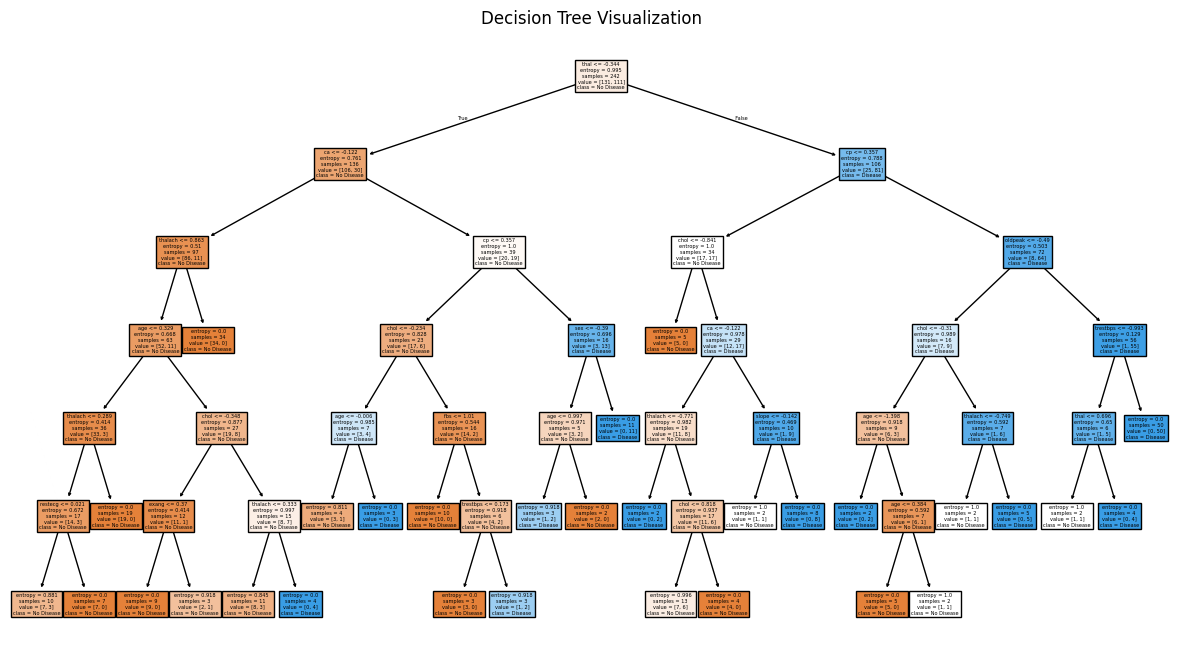

In [65]:
# Decision Tree Classifier for Heart Disease Prediction
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Initialize Decision Tree with optimized parameters
dt = DecisionTreeClassifier(
    criterion='entropy',    # 'gini' or 'entropy'
    max_depth=6,            # limit tree depth to prevent overfitting
    min_samples_split=5,    # minimum samples per split
    min_samples_leaf=2,     # minimum samples per leaf node
    splitter='best',        # choose best split strategy
    random_state=42
)

# Train the model
dt.fit(X_train_scaled, y_train)

# Make predictions
y_pred = dt.predict(X_test_scaled)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f" Decision Tree Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix visualization
conf_matrix_df = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Optional: Visualize the Decision Tree structure (useful for report)
plt.figure(figsize=(15,8))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=['No Disease', 'Disease'])
plt.title("Decision Tree Visualization")
plt.show()


In [62]:
conf_matrix_df = confusion_matrix(y_test, y_pred)
print("Confusion Matrix   :", conf_matrix_df)
accuracy_df = accuracy_score(y_test,y_pred)
print("Accuracy   :", accuracy_df)
precision_df = precision_score(y_test, y_pred)
print("Precision :", precision_df)
recall_df = recall_score(y_test, y_pred)
print("Recall    :", recall_df)
F1_score_df = f1_score(y_test, y_pred)
print("F1-score  :", F1_score_df)

Confusion Matrix   : [[29  4]
 [ 2 26]]
Accuracy   : 0.9016393442622951
Precision : 0.8666666666666667
Recall    : 0.9285714285714286
F1-score  : 0.896551724137931


In [68]:
#logistic regression
result1 = ["1.","Logistic Regression"]
result1.append(round(accuracy_lr*100,2))
result1.append(round(precision_lr*100,2))
result1.append(round(recall_lr*100,2))
result1.append(round(F1_score_lr*100,2))

#random forest classifier
result2 = ["2.","Random Forest Classifier"]
result2.append(round(accuracy_rf*100,2))
result2.append(round(precision_rf*100,2))
result2.append(round(recall_rf*100,2))
result2.append(round(F1_score_rf*100,2))

#support vector machine
result3 = ["3.","Support Vector Machine"]
result3.append(round(accuracy_svm*100,2))
result3.append(round(precision_svm*100,2))
result3.append(round(recall_svm*100,2))
result3.append(round(F1_score_svm*100,2))

#knn
result4 = ["4.","K Nearest Neighbours"]
result4.append(round(accuracy_knn*100,2))
result4.append(round(precision_knn*100,2))
result4.append(round(recall_knn*100,2))
result4.append(round(F1_score_knn*100,2))

#xg boost
result5 = ["5.","XG Boost"]
result5.append(round(accuracy_xg*100,2))
result5.append(round(precision_xg*100,2))
result5.append(round(recall_xg*100,2))
result5.append(round(F1_score_xg*100,2))

#xg boost alternate method
result6 = ["6.","XG Boost Alternate method"]
result6.append(round(accuracy_xg_alternate*100,2))
result6.append(round(precision_xg_alternate*100,2))
result6.append(round(recall_xg_alternate*100,2))
result6.append(round(F1_score_xg_alternate*100,2))

#Decision Tree method
result7 = ["7.","Decision Tree method"]
result7.append(round(accuracy_df*100,2))
result7.append(round(precision_df*100,2))
result7.append(round(recall_df*100,2))
result7.append(round(F1_score_df*100,2))

In [67]:
from prettytable import PrettyTable

In [69]:
Result_table = PrettyTable(["S.No.","Model","Accuracy","Precison","Recall","F1 Score"])
Result_table.add_row(result1)
Result_table.add_row(result2)
Result_table.add_row(result3)
Result_table.add_row(result4)
Result_table.add_row(result5)
Result_table.add_row(result6)
Result_table.add_row(result7)
print(Result_table)

+-------+---------------------------+----------+----------+--------+----------+
| S.No. |           Model           | Accuracy | Precison | Recall | F1 Score |
+-------+---------------------------+----------+----------+--------+----------+
|   1.  |    Logistic Regression    |  87.91   |   88.1   | 86.05  |  87.06   |
|   2.  |  Random Forest Classifier |  85.71   |  84.09   | 86.05  |  85.06   |
|   3.  |   Support Vector Machine  |  82.42   |   81.4   |  81.4  |   81.4   |
|   4.  |    K Nearest Neighbours   |  82.42   |   81.4   |  81.4  |   81.4   |
|   5.  |          XG Boost         |  90.16   |  86.67   | 92.86  |  89.66   |
|   6.  | XG Boost Alternate method |  90.16   |  86.67   | 92.86  |  89.66   |
|   7.  |    Decision Tree method   |  90.16   |  86.67   | 92.86  |  89.66   |
+-------+---------------------------+----------+----------+--------+----------+
